# 01 — Data Acquisition, QC & SQL Cohort Assembly

**Author:** Virginia Galván, PhD

PAM50 molecular subtype (Luminal A, Luminal B, HER2-enriched, Basal-like, Normal-like) and matched gene expression for TCGA Breast Invasive Carcinoma (BRCA), PanCancer Atlas cohort, pulled from cBioPortal's public REST API. This notebook queries clinical subtype labels and expression values for the standardized PAM50 50-gene panel directly (no bulk file download), runs QC and exploratory analysis, then loads the clean table into SQL and assembles the final modeling cohort with a SQL query — producing the cohort table used for modeling in Notebook 02.

**Requires internet access** to reach the cBioPortal API (`www.cbioportal.org/api`). Designed to run in Google Colab or locally.

In [1]:
import os
import sqlite3

import requests
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

IN_COLAB = "google.colab" in str(get_ipython())
DATA_DIR = "." if IN_COLAB else "../data"
FIGURES_DIR = "." if IN_COLAB else "../figures"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

API_BASE = "https://www.cbioportal.org/api"
STUDY_ID = "brca_tcga_pan_can_atlas_2018"

session = requests.Session()
session.headers.update({"Accept": "application/json"})

## 1. Data acquisition

Study: `brca_tcga_pan_can_atlas_2018` (TCGA, Breast Invasive Carcinoma, PanCancer Atlas). Clinical and expression data are pulled directly from cBioPortal's REST API — no bulk tarball download or local file extraction required.

## 2. Clinical data — PAM50 subtype

Patient-level clinical annotations include the `SUBTYPE` field (PAM50 call). Sample-level annotations provide the `PATIENT_ID` ↔ `SAMPLE_ID` mapping needed to join against expression data.

In [2]:
clinical_response = session.get(
    f"{API_BASE}/studies/{STUDY_ID}/clinical-data",
    params={"clinicalDataType": "PATIENT", "attributeId": "SUBTYPE", "projection": "SUMMARY"},
)
clinical_response.raise_for_status()

clinical = pd.DataFrame(clinical_response.json())[["patientId", "value"]]
clinical = clinical.rename(columns={"patientId": "PATIENT_ID", "value": "SUBTYPE"})
clinical["SUBTYPE"] = clinical["SUBTYPE"].str.replace("BRCA_", "", regex=False)
clinical.head()

,PATIENT_ID,SUBTYPE
0,TCGA-3C-AAAU,LumA
1,TCGA-3C-AALI,Her2
2,TCGA-3C-AALJ,LumB
3,TCGA-3C-AALK,LumA
4,TCGA-4H-AAAK,LumA


## 3. Expression data — PAM50 gene panel

The PAM50 classifier (Parker et al. 2009, *J Clin Oncol*) is defined over a standardized 50-gene panel. Gene symbols are resolved to Entrez IDs, the study's mRNA expression (RNA Seq V2 RSEM, z-scores relative to diploid samples) molecular profile is located, and expression values for this panel are queried for all profiled samples.

In [3]:
PAM50_GENES = [
    "ACTR3B", "ANLN", "BAG1", "BCL2", "BIRC5", "BLVRA", "CCNB1", "CCNE1",
    "CDC20", "CDC6", "CDH3", "CENPF", "CEP55", "CXXC5", "EGFR", "ERBB2",
    "ESR1", "EXO1", "FGFR4", "FOXA1", "FOXC1", "GPR160", "GRB7", "KIF2C",
    "KRT14", "KRT17", "KRT5", "MAPT", "MDM2", "MELK", "MIA", "MKI67",
    "MLPH", "MMP11", "MYBL2", "MYC", "NAT1", "NDC80", "NUF2", "ORC6",
    "PGR", "PHGDH", "PTTG1", "RRM2", "SFRP1", "SLC39A6", "TMEM45B",
    "TYMS", "UBE2C", "UBE2T",
]

gene_response = session.post(
    f"{API_BASE}/genes/fetch",
    params={"geneIdType": "HUGO_GENE_SYMBOL", "projection": "SUMMARY"},
    json=PAM50_GENES,
)
gene_response.raise_for_status()

genes = pd.DataFrame(gene_response.json())[["entrezGeneId", "hugoGeneSymbol"]]
entrez_to_symbol = dict(zip(genes["entrezGeneId"], genes["hugoGeneSymbol"]))

profiles_response = session.get(f"{API_BASE}/studies/{STUDY_ID}/molecular-profiles")
profiles_response.raise_for_status()
profiles = pd.DataFrame(profiles_response.json())

expression_profile = profiles[
    (profiles["molecularAlterationType"] == "MRNA_EXPRESSION")
    & profiles["molecularProfileId"].str.contains("Zscores", case=False)
].iloc[0]
MOLECULAR_PROFILE_ID = expression_profile["molecularProfileId"]
MOLECULAR_PROFILE_ID

'brca_tcga_pan_can_atlas_2018_rna_seq_v2_mrna_median_Zscores'

In [4]:
molecular_response = session.post(
    f"{API_BASE}/molecular-profiles/{MOLECULAR_PROFILE_ID}/molecular-data/fetch",
    params={"projection": "SUMMARY"},
    json={
        "entrezGeneIds": genes["entrezGeneId"].tolist(),
        "sampleListId": f"{STUDY_ID}_all",
    },
)
molecular_response.raise_for_status()

expression_long = pd.DataFrame(molecular_response.json())
expression_long["hugoGeneSymbol"] = expression_long["entrezGeneId"].map(entrez_to_symbol)

expression_panel = expression_long.pivot_table(
    index=["sampleId", "patientId"], columns="hugoGeneSymbol", values="value"
).reset_index()
expression_panel = expression_panel.rename(
    columns={"sampleId": "SAMPLE_ID", "patientId": "PATIENT_ID"}
)
expression_panel.shape

(1082, 52)

## 4. Merge and QC

Clinical subtype labels and PAM50 expression values are joined on `PATIENT_ID`. Rows with any missing PAM50 gene value are dropped, since the modeling notebook requires a complete feature matrix.

In [5]:
dataset = expression_panel.merge(clinical, on="PATIENT_ID", how="inner")
dataset = dataset.dropna(subset=PAM50_GENES)

print(f"Patients: {dataset['PATIENT_ID'].nunique()}")
print(f"Samples: {dataset['SAMPLE_ID'].nunique()}")
print(f"Features: {len(PAM50_GENES)} PAM50 genes")
dataset["SUBTYPE"].value_counts()

Patients: 981
Samples: 981
Features: 50 PAM50 genes


,count
SUBTYPE,
LumA,499
LumB,197
Basal,171
Her2,78
Normal,36


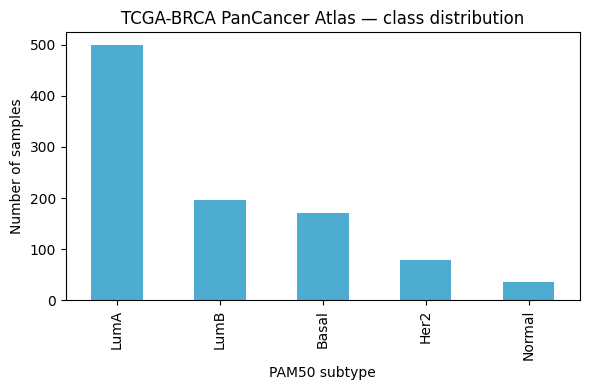

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
dataset["SUBTYPE"].value_counts().plot(kind="bar", ax=ax, color="#4EACD1")
ax.set_xlabel("PAM50 subtype")
ax.set_ylabel("Number of samples")
ax.set_title("TCGA-BRCA PanCancer Atlas — class distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig1_subtype_class_distribution.png"), dpi=150)
plt.show()

Subtype classes are imbalanced (Luminal A is substantially more frequent than the other four), which is consistent with population-level PAM50 distributions reported for breast cancer cohorts. This is addressed explicitly in Notebook 02 through stratified cross-validation and class-weighted models rather than ignored.

## 5. Exploratory data analysis

The PAM50 panel is examined for structure before modeling: whether samples separate by subtype in expression space, how the 50 genes correlate with each other, and whether well-characterized subtype markers behave as expected.

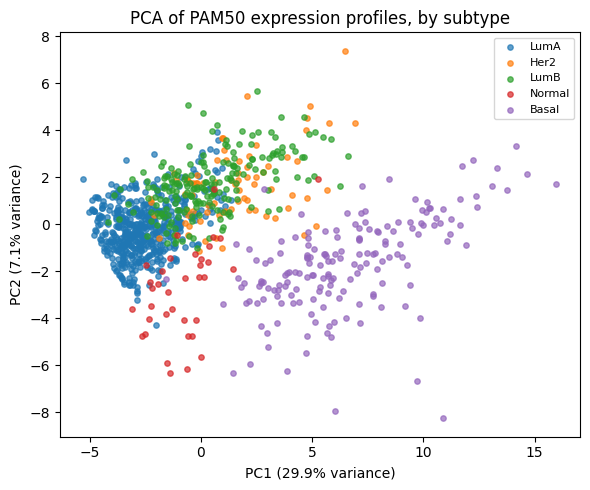

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = dataset[PAM50_GENES].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
subtypes = dataset["SUBTYPE"].unique()
for subtype in subtypes:
    mask = dataset["SUBTYPE"] == subtype
    ax.scatter(coords[mask, 0], coords[mask, 1], label=subtype, s=15, alpha=0.7)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA of PAM50 expression profiles, by subtype")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig2_pca_by_subtype.png"), dpi=150)
plt.show()

Samples form partially overlapping clusters that align with PAM50 subtype along the first two principal components, consistent with PAM50 being defined directly from expression patterns in this gene panel. Overlap between adjacent subtypes (e.g. Luminal A / Luminal B) is expected biologically, since these represent a graded hormone-receptor and proliferation axis rather than fully discrete categories.

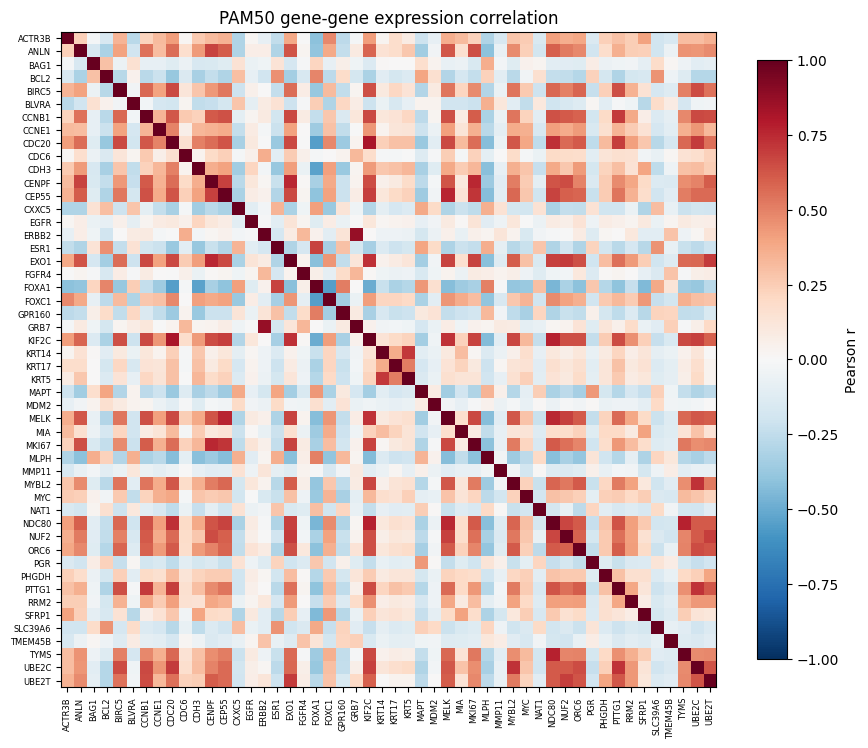

In [8]:
corr = dataset[PAM50_GENES].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(PAM50_GENES)))
ax.set_yticks(range(len(PAM50_GENES)))
ax.set_xticklabels(PAM50_GENES, rotation=90, fontsize=6)
ax.set_yticklabels(PAM50_GENES, fontsize=6)
ax.set_title("PAM50 gene-gene expression correlation")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig3_gene_correlation_heatmap.png"), dpi=150)
plt.show()

Proliferation genes (e.g. MKI67, BIRC5, CCNB1, RRM2) form a tight positive-correlation block, as do hormone-receptor-pathway genes (e.g. ESR1, PGR, FOXA1) — both are recognized co-expression modules in breast cancer transcriptomics. This correlation structure is relevant for Notebook 03, where feature importance is interpreted at the level of these modules rather than treating each gene as fully independent.

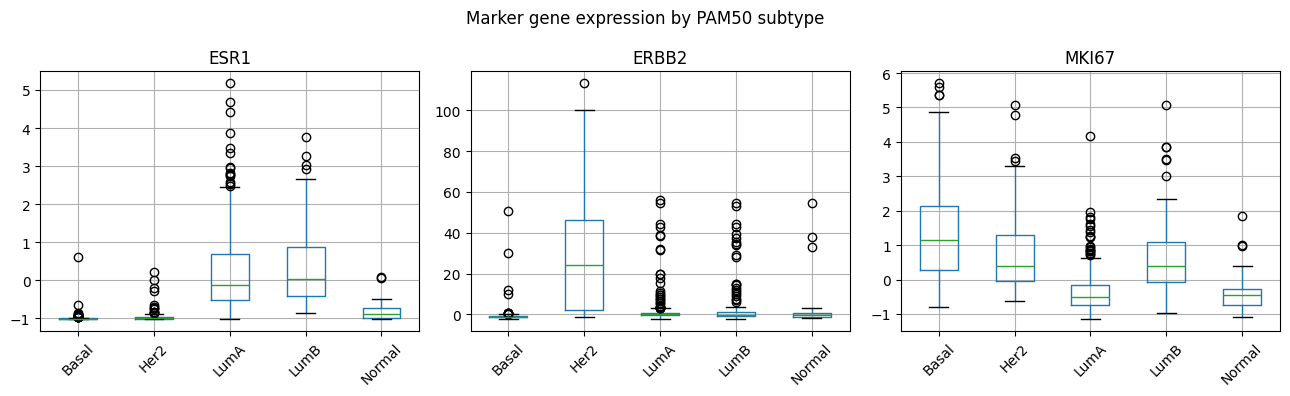

In [9]:
marker_genes = ["ESR1", "ERBB2", "MKI67"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, gene in zip(axes, marker_genes):
    dataset.boxplot(column=gene, by="SUBTYPE", ax=ax, rot=45)
    ax.set_title(gene)
    ax.set_xlabel("")

fig.suptitle("Marker gene expression by PAM50 subtype")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig4_marker_genes_by_subtype.png"), dpi=150)
plt.show()

ESR1 is highest in Luminal A/B, ERBB2 is highest in HER2-enriched, and MKI67 (a proliferation marker) is highest in Basal-like — matching the established clinical and molecular definition of each subtype. This is a direct biological sanity check on the expression data prior to modeling.

## 6. Load data into SQL

The clean, QC'd patient-level table from Notebook section 5 is loaded into a SQLite database. SQLite is used here for portability (a single file, no server to provision or expire) — the same code runs unchanged against Postgres by swapping the SQLAlchemy connection string.

In [10]:
db_path = os.path.join(DATA_DIR, "brca_pam50.db")
engine = create_engine(f"sqlite:///{db_path}")
dataset.to_sql("brca_pam50", engine, if_exists="replace", index=False)

f"{len(dataset)} rows loaded into brca_pam50"

'981 rows loaded into brca_pam50'

## 7. Cohort assembly via SQL

The modeling cohort — patient/sample identifiers, subtype label, and PAM50 gene features — is assembled with a SQL query. A second query aggregates sample counts per subtype directly in the database, as a quick sanity check against the class distribution already seen above.

In [11]:
gene_columns_sql = ", ".join(f'"{gene}"' for gene in PAM50_GENES)

cohort_query = f"""
    SELECT PATIENT_ID, SAMPLE_ID, SUBTYPE, {gene_columns_sql}
    FROM brca_pam50
    WHERE SUBTYPE IS NOT NULL
"""

with engine.connect() as conn:
    cohort = pd.read_sql(text(cohort_query), conn)
    subtype_counts = pd.read_sql(
        text("SELECT SUBTYPE, COUNT(*) AS n_samples FROM brca_pam50 "
             "GROUP BY SUBTYPE ORDER BY n_samples DESC"),
        conn,
    )

subtype_counts

,SUBTYPE,n_samples
0,LumA,499
1,LumB,197
2,Basal,171
3,Her2,78
4,Normal,36


## 8. Export cohort

The SQL-assembled cohort is saved to CSV for Notebook 02 — the only file handoff between the two notebooks.

In [12]:
cohort_path = os.path.join(DATA_DIR, "brca_pam50_cohort.csv")
cohort.to_csv(cohort_path, index=False)
cohort_path

'./brca_pam50_cohort.csv'